# AKNA B-cell binding-site distribution and IGV preparation

## Purpose

**Author: Raquel A. Romao**

This notebook prepares B-cell AKNA iCLIP2 outputs for manuscript figures and
genome-browser inspection. Its primary input is the signal-comparison workbook
from analysis 03, containing WT-defined reproducible sites and their WT/KO ratios.

The analysis covers:
1. Counts of reproducible and WT-enriched binding sites and distinct target genes.
2. Binding-site distribution across 5′ UTR, CDS, 3′ UTR and intronic regions.
3. Manually curated loci for comparing WT and KO crosslink tracks in IGV.
4. Export of the enriched-site BED and arithmetic-mean replicate tracks.

The gene-body distribution uses sites with **WT/KO ratio >1.5**, while a separate
summary describes all reproducible sites. Gene counts and binding-site counts are
kept distinct throughout.

**Outputs:** region source tables/workbook, pie and bar plots, an IGV navigation
table, the enriched BED, and four group-average BigWigs under `output_dir`.
The corrected GO analysis and plot are generated separately by
[`04_go_wt_ko_enriched.R`](04_go_wt_ko_enriched.R).

## Input/output configuration

Edit these paths before running the analysis. Relative paths are resolved from the repository root. Run the cells in order using the R kernel.

`primary_workbook` must contain the `all_reproducible_binding_sites` sheet from
analysis 03. `wt_tracks_dir` and `ko_tracks_dir` hold the individual normalized
BigWigs named by sample and strand. The notebook reads these inputs and writes
derived tables, plots, and tracks under `output_dir`.

In [1]:
params <- list(
  primary_workbook = "results/analysis/03_signal_comparison/reproducible_binding_sites_groups_noKO_signal_comparison.xlsx",
  wt_tracks_dir = "results/preprocessing/akna/crosslinked_nucleotides",
  ko_tracks_dir = "results/preprocessing/akna/crosslinked_nucleotides",
  output_dir = "results/analysis/05_manuscript_figures"
)

project_root <- normalizePath(getwd(), mustWork = TRUE)
if (!file.exists(file.path(project_root, "workflow", "Snakefile"))) {
  project_root <- normalizePath(file.path(project_root, ".."), mustWork = TRUE)
}
if (!file.exists(file.path(project_root, "workflow", "Snakefile"))) {
  stop("Open this notebook from the repository root or its analysis directory.")
}
resolve_repo_path <- function(path) {
  if (grepl("^(/|[A-Za-z]:[/\\\\])", path)) path else file.path(project_root, path)
}
paths <- lapply(params, resolve_repo_path)


## Setup: plotting and workbook helpers

Use a common plotting theme and export plots as PDF and PNG. Before writing
Excel sheets, convert any list-valued metadata to semicolon-separated strings.

In [2]:

library(readxl)
library(dplyr)
library(ggplot2)
library(stringr)
library(forcats)
library(scales)
library(readr)
library(writexl)

out_dir <- paths$output_dir
dir.create(out_dir, recursive = TRUE, showWarnings = FALSE)
theme_set(theme_classic(base_size = 12))

# Save matching vector and raster versions of each plot.
save_plot <- function(plot, name, width = 6, height = 4) {
  ggsave(
    file.path(out_dir, paste0(name, ".pdf")), plot,
    width = width, height = height, useDingbats = FALSE
  )
  ggsave(
    file.path(out_dir, paste0(name, ".png")), plot,
    width = width, height = height, dpi = 300
  )
}

# Flatten list-valued annotation columns before tabular export.
clean_list_columns <- function(data) {
  data[] <- lapply(data, function(column) {
    if (is.list(column)) {
      vapply(column, paste, collapse = ";", FUN.VALUE = character(1))
    } else {
      column
    }
  })
  data
}

write_workbook <- function(sheets, path) {
  sheets <- lapply(sheets, function(x) clean_list_columns(as.data.frame(x)))
  writexl::write_xlsx(sheets, path)
}


## Load primary data

Read the annotated-site sheet and set the region display order to 5′ UTR, CDS,
3′ UTR and intron. WT_mean and KO_mean are averages of per-site normalized signal;
fold_change is their pseudocount-adjusted ratio. The boolean pass_threshold field
records the strict WT/KO enrichment criterion from analysis 03.

In [3]:
stopifnot(file.exists(paths$primary_workbook))
bs <- read_excel(
  paths$primary_workbook,
  sheet = "all_reproducible_binding_sites"
) %>%
  mutate(
    region = factor(region, levels = c("utr5", "cds", "utr3", "intron")),
    pass_threshold = as.logical(pass_threshold),
    WT_mean = as.numeric(WT_mean),
    KO_mean = as.numeric(KO_mean),
    fold_change = as.numeric(fold_change)
  )

message("Primary binding-site rows: ", nrow(bs))
message("Unique target genes: ", n_distinct(bs$gene_name))


Primary binding-site rows: 2853


Unique target genes: 1351


## Site-set summary

Report the number of sites and distinct genes before and after WT/KO filtering.
Several sites can belong to one gene, so the two counts answer different questions.
The table documents the 2,853-site reproducible set and 2,412-site enriched subset.

In [4]:
threshold_summary <- tibble(
  selection = c("all reproducible binding sites", "fold_change > 1.5"),
  n_binding_sites = c(nrow(bs), sum(bs$pass_threshold, na.rm = TRUE)),
  n_genes = c(
    n_distinct(bs$gene_name),
    n_distinct(bs$gene_name[bs$pass_threshold])
  )
)
write_csv(threshold_summary, file.path(out_dir, "threshold_summary.csv"))
threshold_summary


  selection                      n_binding_sites n_genes
1 all reproducible binding sites 2853            1351   
2 fold_change > 1.5              2412            1243   

## Binding-site position: region summaries and plots

Use the gene-body annotation assigned in analysis 02. Each site contributes once
to its assigned region, and the fractions sum across sites rather than genes.
These are distributions of binding sites, not enrichment relative to region length.

Export summaries for both the full reproducible set and the WT-enriched subset.
The pie and bar plots use only the enriched subset; its per-site source table is
also written to CSV/Excel so the plotted counts can be inspected directly.

In [5]:
format_region_summary <- function(data) {
  data %>%
    count(region, name = "n") %>%
    mutate(
      fraction = n / sum(n),
      region_label = str_replace_all(
        as.character(region),
        c("utr5" = "5' UTR", "utr3" = "3' UTR", "cds" = "CDS",
          "intron" = "Intron")
      ),
      label = paste0(
        region_label, "\n", n, " (", percent(fraction, accuracy = 0.1), ")"
      )
    )
}

# Keep the all-reproducible summary separate from the enriched plot source.
region_summary_all <- format_region_summary(bs)
region_summary <- bs %>% filter(pass_threshold) %>% format_region_summary()
region_plot_source <- bs %>%
  filter(pass_threshold) %>%
  mutate(region = as.character(region))

write_csv(region_summary_all, file.path(out_dir, "binding_site_region_summary_all_reproducible.csv"))
write_csv(region_summary, file.path(out_dir, "binding_site_region_summary_WT_KO_enriched.csv"))
write_csv(region_plot_source, file.path(out_dir, "binding_site_region_plot_source_WT_KO_enriched.csv"))
write_workbook(
  list(
    region_summary_WT_KO_enriched = region_summary,
    region_summary_all_reproducible = region_summary_all,
    WT_KO_enriched_binding_sites = region_plot_source
  ),
  file.path(out_dir, "AKNA_noKO_binding_site_region_distribution_WT_KO_enriched.xlsx")
)


### Plot the WT-enriched region distribution

Keep the same region colours in both plots. The pie chart labels each segment
with its count and percentage; the bar chart shows the corresponding counts.
The cumulative fractions position the pie segments and their external labels.

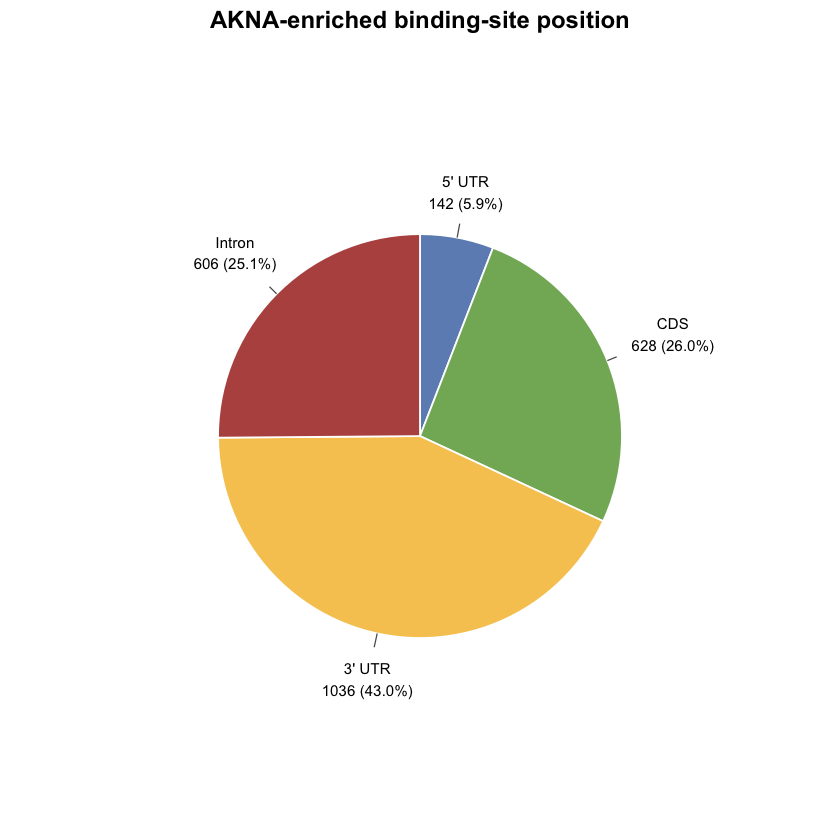

In [6]:
region_palette <- c(
  "utr5" = "#6C8EBF", "cds" = "#82B366",
  "utr3" = "#F6C85F", "intron" = "#B85450"
)
# Compute segment boundaries and label positions from the enriched fractions.
region_summary_pie <- region_summary %>%
  arrange(region) %>%
  mutate(
    ymax = cumsum(fraction),
    ymin = lag(ymax, default = 0),
    label_pos = (ymin + ymax) / 2,
    tick_end = if_else(region %in% c("cds", "intron"), 1.05, 1.07),
    label_x = case_when(
      region == "cds" ~ 1.35,
      region == "intron" ~ 1.29,
      TRUE ~ 1.23
    )
  )

p_region_pie <- ggplot(region_summary_pie, aes(fill = region)) +
  geom_rect(
    aes(xmin = 0, xmax = 1, ymin = ymin, ymax = ymax),
    color = "white", linewidth = 0.5
  ) +
  geom_segment(
    aes(x = 1, xend = tick_end, y = label_pos, yend = label_pos),
    color = "grey35", linewidth = 0.35
  ) +
  geom_text(aes(x = label_x, y = label_pos, label = label), size = 3.2) +
  coord_polar(theta = "y") +
  xlim(0, 1.6) +
  scale_fill_manual(values = region_palette, drop = FALSE) +
  labs(title = "AKNA-enriched binding-site position") +
  theme_void(base_size = 12) +
  theme(plot.title = element_text(hjust = 0.5, face = "bold"),
        legend.position = "none")
p_region_pie
save_plot(p_region_pie, "figure_binding_site_region_pie", 5.5, 5.5)

# Plot the same enriched counts as bars using the same region palette.
p_region_bar <- region_summary %>%
  mutate(region_label = fct_recode(
    region, "5' UTR" = "utr5", "CDS" = "cds",
    "3' UTR" = "utr3", "Intron" = "intron"
  )) %>%
  ggplot(aes(x = region_label, y = n, fill = region)) +
  geom_col(width = 0.72) +
  geom_text(aes(label = n), vjust = -0.35) +
  scale_fill_manual(values = region_palette, guide = "none", drop = FALSE) +
  labs(x = NULL, y = "Binding sites",
       title = "AKNA-enriched binding sites by gene-body region") +
  expand_limits(y = max(region_summary$n) * 1.12)
save_plot(p_region_bar, "figure_binding_site_region_bar", 5, 3.5)


# Loci for IGV inspection

These examples were manually curated using binding-site evidence and biological relevance. They can be adjusted interactively in IGV.

In [7]:
igv_loci <- tibble::tribble(
  ~gene_name, ~chromosome, ~start, ~end, ~strand, ~role,
  "Cdc42", "chr4", 137318560L, 137330560L, "-", "binding example",
  "Iqgap1", "chr7", 80711973L, 80713981L, "-", "binding example",
  "Pafah1b1", "chr11", 74676189L, 74676966L, "-", "binding example",
  "Rpsa", "chr9", 120131186L, 120131782L, "+", "binding example",
  "Eif3e", "chr15", 43282378L, 43282854L, "-", "binding example",
  "Msn", "chrX", 96168170L, 96168574L, "+", "binding example",
  "Tubb5", "chr17", 35834935L, 35837546L, "-", "binding example",
  "Cd79a", "chr7", 24898655L, 24900637L, "+", "binding example",
  "Cd40", "chr2", 165055000L, 165070000L, "+", "comparison overview"
) %>%
  mutate(igv_locus = paste0(chromosome, ":", start, "-", end))
write_csv(igv_loci, file.path(out_dir, "igv_loci.csv"))
igv_loci


## Export WT-enriched binding sites for IGV

Use the same pass_threshold flag as the region plots. Verify it agrees with
fold_change >1.5, then convert 1-based inclusive workbook intervals to BED6 by
subtracting one from the start only.

In [8]:
# Export BED6: workbook coordinates are 1-based inclusive; BED starts are 0-based.
stopifnot(
  !anyNA(bs$fold_change), !anyNA(bs$pass_threshold),
  all(bs$pass_threshold == (bs$fold_change > 1.5))
)
enriched_sites <- bs %>% filter(pass_threshold)
stopifnot(
  all(enriched_sites$end - enriched_sites$start + 1 == 9),
  all(enriched_sites$start >= 1),
  all(enriched_sites$strand %in% c("+", "-"))
)
enriched_bed <- enriched_sites %>%
  transmute(
    chrom = seqnames, start = start - 1L, end = end,
    name = gene_name, score = 0L, strand = strand
  ) %>%
  arrange(chrom, start, end, strand)
write_tsv(
  enriched_bed, file.path(out_dir, "final_WT_KO_enriched_binding_sites.bed"),
  col_names = FALSE
)
cat("Exported enriched sites:", nrow(enriched_bed), "\n")


Exported enriched sites: 2412 


## Replicate-average signal tracks

Each input BigWig must contain nonnegative, strand-specific crosslink signal
already normalized per library. For each genomic position, sum the three WT
or two KO replicate signals and divide by the number of replicates. Uncovered
positions contribute zero; pooled-library tracks are not used. As in the
existing average tracks, only chromosomes present in every input replicate
are exported. Omitted scaffolds are reported. Missing files or incompatible
lengths for shared chromosomes stop this step.

Load the four output BigWigs and the enriched-site BED manually in IGV with
the mm10 genome, then paste a coordinate from `igv_loci.csv` into the search box.
Use a shared vertical scale for WT and KO when comparing their signal.

In [9]:
average_bigwigs <- function(input_files, output_file) {
  missing <- input_files[!file.exists(input_files)]
  if (length(missing)) stop("Missing replicate tracks: ", paste(missing, collapse = ", "))
  # Inspect sequence lengths before arithmetic on the run-length encoded tracks.
  headers <- lapply(input_files, function(path) {
    GenomeInfoDb::seqlengths(rtracklayer::BigWigFile(path))
  })
  # Preserve the shared-chromosome convention of the existing group averages.
  common <- Reduce(intersect, lapply(headers, names))
  if (!length(common)) stop("No shared chromosomes in replicate tracks.")
  omitted <- setdiff(Reduce(union, lapply(headers, names)), common)
  if (length(omitted)) message("Scaffolds absent from one or more replicates; omitted: ", paste(omitted, collapse = ", "))
  reference <- headers[[1]][common]
  for (header in headers) {
    if (!identical(unname(reference), unname(header[common]))) {
      stop("Shared chromosomes must have matching lengths.")
    }
  }
  # Add individual normalized tracks, then divide by the number of replicates.
  total <- NULL
  for (path in input_files) {
    signal <- rtracklayer::import(path, format = "BigWig", as = "Rle")
    signal <- signal[names(reference)]
    if (any(vapply(signal, function(x) anyNA(x) || min(x) < 0, logical(1)))) {
      stop("Expected nonnegative normalized signal without missing values: ", path)
    }
    if (is.null(total)) total <- signal else total <- total + signal
  }
  rtracklayer::export(total / length(input_files), output_file, format = "BigWig")
}

for (strand in c("plus", "minus")) {
  average_bigwigs(
    file.path(paths$wt_tracks_dir, paste0(c("WT1", "WT2", "WT3"), ".", strand, ".bw")),
    file.path(out_dir, paste0("WT.average.", strand, ".bw"))
  )
  average_bigwigs(
    file.path(paths$ko_tracks_dir, paste0(c("KO1", "KO2"), ".", strand, ".bw")),
    file.path(out_dir, paste0("KO.average.", strand, ".bw"))
  )
}


## Session information

Print the R and package versions available to the kernel for this execution.

In [10]:
sessionInfo()
